### Experiment 4 - Binary Classification using Linear and Kernel-Based Models

Priya Verma  | Class: CSE B | Reg. No: 3122235001102

### Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import time
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import math

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 15,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 15,
    "axes.labelweight": "bold",
    "xtick.labelsize": 13,
    "ytick.labelsize": 13
})


### 1. Load the dataset

In [ ]:
# loading dataset
df = pd.read_csv("datasets/spambase_csv_Kaggle.csv")


In [123]:
df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

In [125]:
df.columns

Index(['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
       'word_freq_our', 'word_freq_over', 'word_freq_remove',
       'word_freq_internet', 'word_freq_order', 'word_freq_mail',
       'word_freq_receive', 'word_freq_will', 'word_freq_people',
       'word_freq_report', 'word_freq_addresses', 'word_freq_free',
       'word_freq_business', 'word_freq_email', 'word_freq_you',
       'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000',
       'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george',
       'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet',
       'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
       'word_freq_technology', 'word_freq_1999', 'word_freq_parts',
       'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting',
       'word_freq_original', 'word_freq_project', 'word_freq_re',
       'word_freq_edu', 'word_freq_table', 'word_freq_conference',


### 2. Perform data preprocessing:

In [ ]:
## Checking if any duplicate rows are found.
print("Duplicates in data: ", any(df.duplicated()))

Duplicates in data:  True


In [6]:
## Remove duplicates rows.
df = df.drop_duplicates()
print("Duplicates in data: ", any(df.duplicated()))

# Checking the missing and null values...for train data
print("Any Missing Values: ", any(df.isnull().sum()))

Duplicates in data:  False
Any Missing Values:  False


#### Handling Missing Values

In [ ]:
# Checking the missing and null values...for train data
print("Any Missing Values: ", any(df.isnull().sum()))

Any Missing Values:  False


In [129]:
## Separate features (X) and target (y)
X = df.drop('class', axis=1)
y = df['class']

### 3. Perform Exploratory Data Analysis (EDA)

In [130]:
## Statistical summary for train data
df.describe()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
count,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,...,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000
mean,0.104366,0.112656,0.291473,0.063078,0.325321,0.096656,0.117475,0.108000,0.091860,0.248420,...,0.040403,0.144048,0.017376,0.281136,0.076057,0.045798,5.383896,52.139905,291.181948,0.398812
std,0.300005,0.454260,0.515719,1.352487,0.687805,0.276030,0.397284,0.410282,0.282144,0.656638,...,0.252533,0.274256,0.105731,0.843321,0.239708,0.435925,33.147358,199.582168,618.654838,0.489712
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.627500,7.000000,40.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.073000,0.000000,0.016000,0.000000,0.000000,2.297000,15.000000,101.500000,0.000000
75%,0.000000,0.000000,0.440000,0.000000,0.410000,0.000000,0.000000,0.000000,0.000000,0.190000,...,0.000000,0.194000,0.000000,0.331000,0.053000,0.000000,3.706750,44.000000,273.750000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000


In [131]:
print("Shape of dataset: ",df.shape)

Shape of dataset:  (4210, 58)


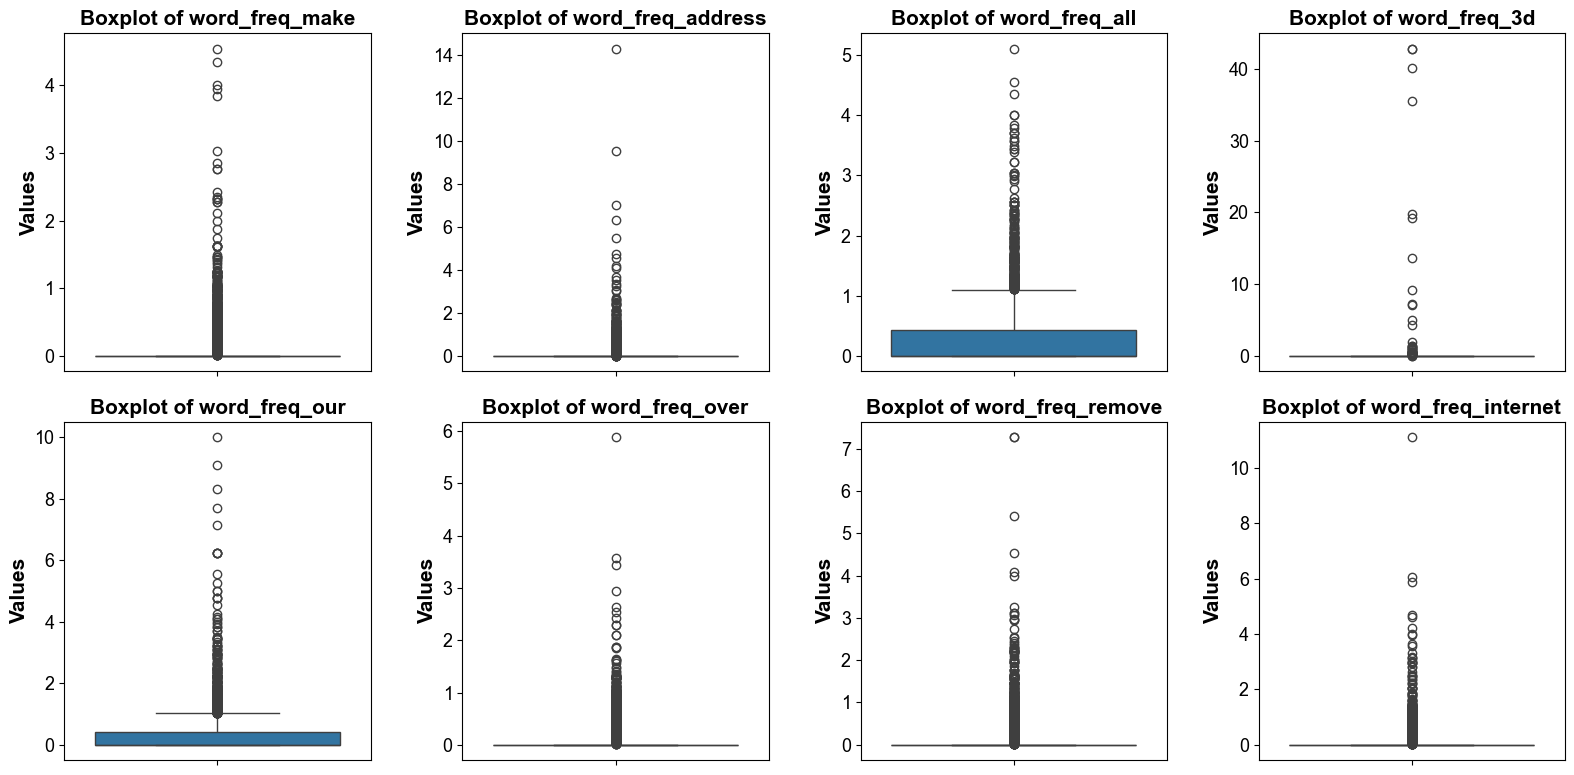

In [132]:
# Boxplot for outliers.
# Select only 8 features
selected_features = X.columns[:8]
X_subset = X[selected_features]

n_cols = 4   # 4 plots per row
n_rows = 2   # 2 rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(X_subset.columns):
    sns.boxplot(y=X_subset[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Values')

# Remove empty plots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [133]:
# Handling outliers by using capping.

cols = df.drop(columns='class', axis = 1)
for col in cols:
    upper_limit = df[col].quantile(0.95)
    lower_limit = df[col].quantile(0.05)
    df[col] = np.where(df[col]>upper_limit, upper_limit, np.where(df[col]<lower_limit, lower_limit, df[col]))


In [134]:
## Separate features (X) and target (y) again after handling outliers.
X = df.drop('class', axis=1)
y = df['class']

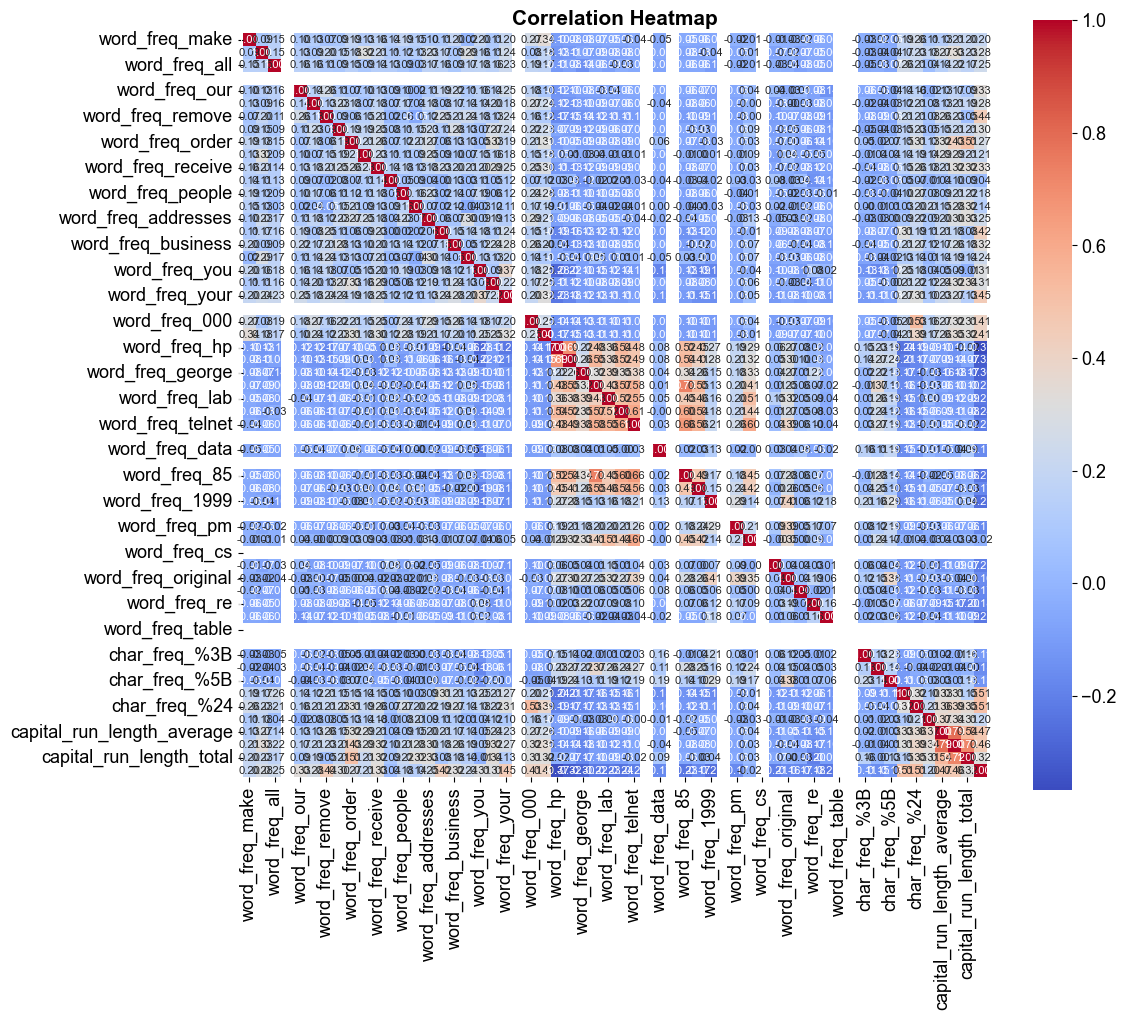

In [135]:
## Correlation analysis
corr = df.corr()

## Heatmap plot for correlation analysis
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    annot_kws={"size": 8}
)
plt.title("Correlation Heatmap")
plt.show()


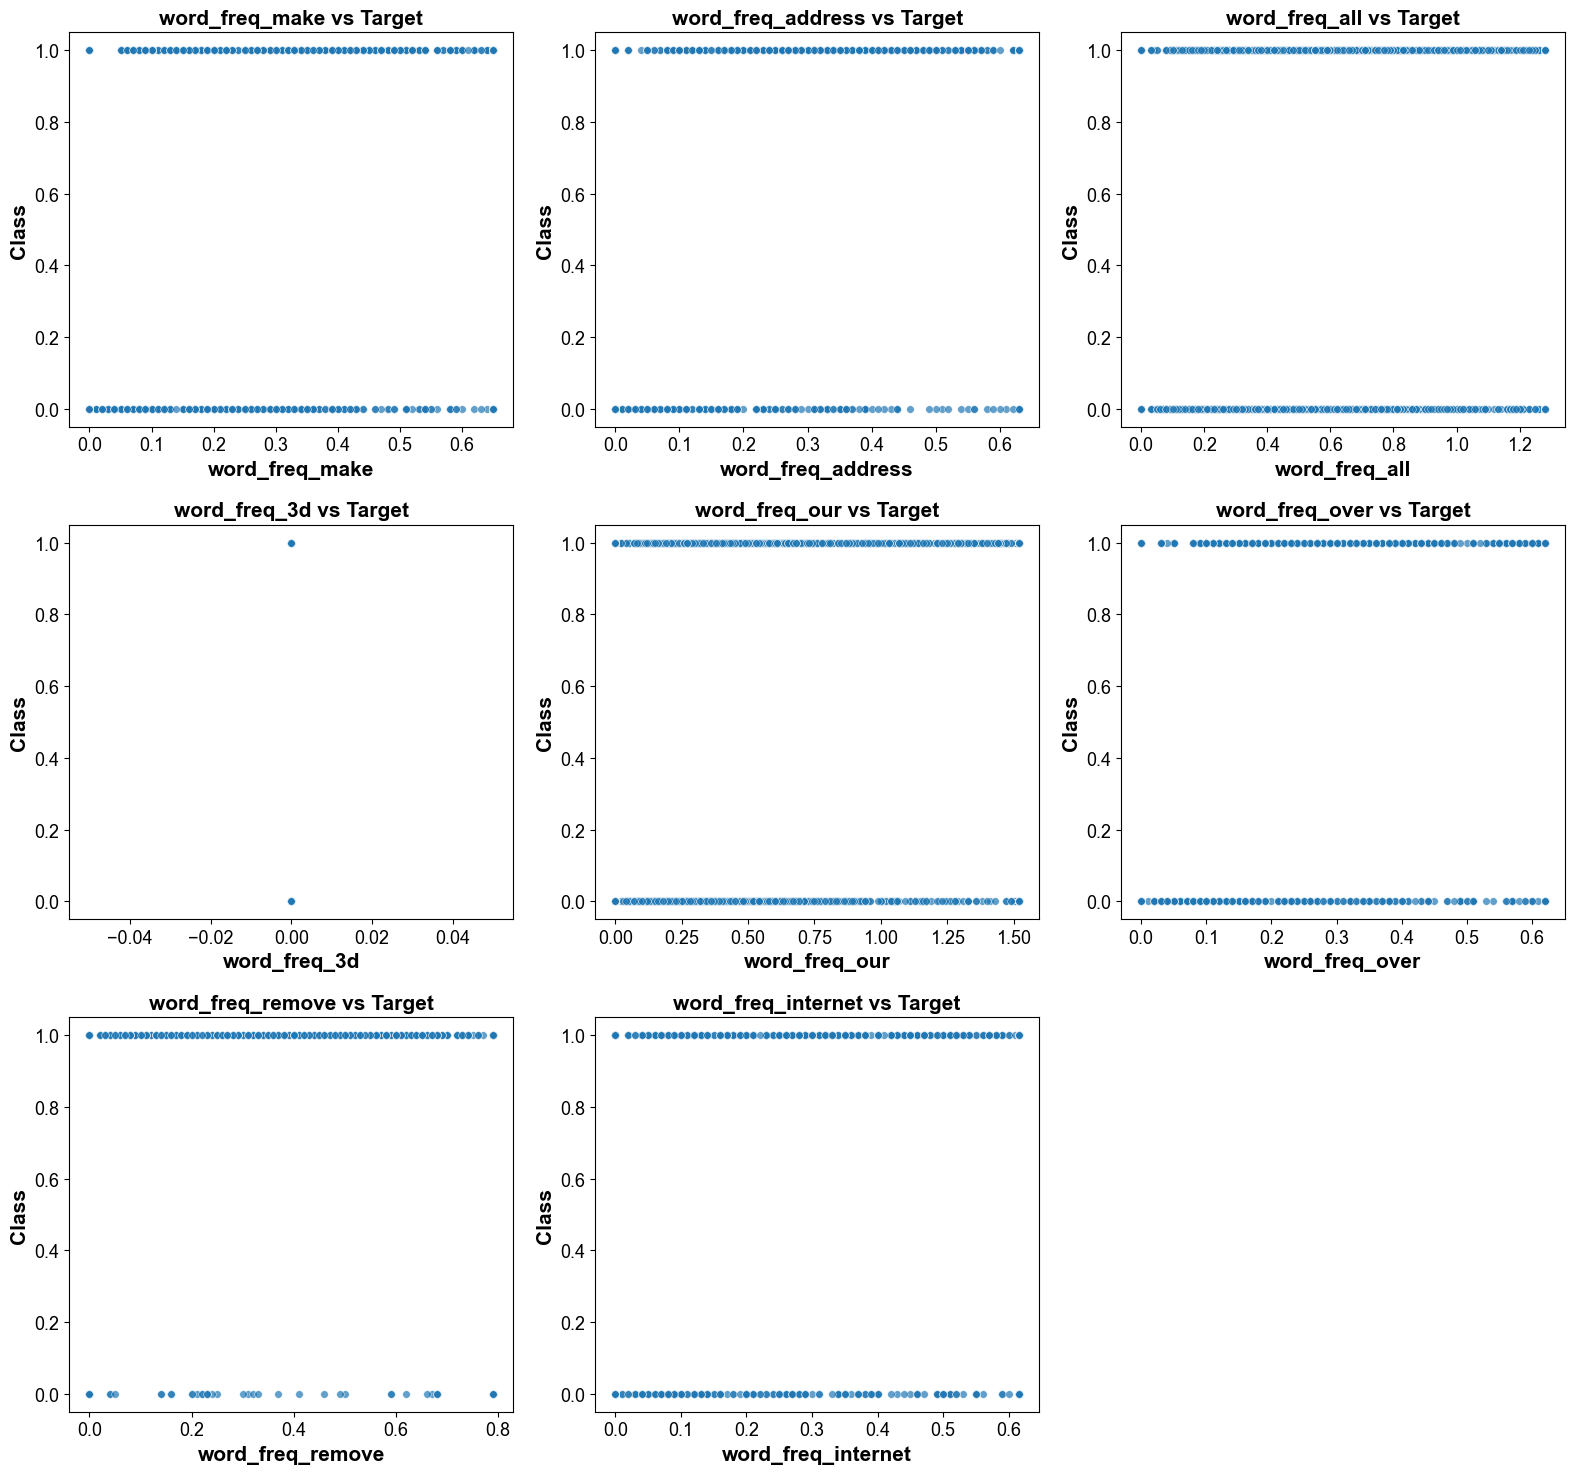

In [136]:
# Feature vs. target scatter plots
# Select numerical features (exclude target if numeric)
num_features = df.select_dtypes(include=['int64', 'float64']).columns
num_features = num_features.drop('class', errors='ignore')

# Select only first 8 features
selected_features = num_features[:8]

n_cols = 3
n_rows = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 15))
axes = axes.flatten()

for i, col in enumerate(selected_features):
    sns.scatterplot(
        x=df[col],
        y=df["class"],
        ax=axes[i],
        s=30,
        alpha=0.7
    )
    axes[i].set_title(f"{col} vs Target")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Class")

# Remove unused subplots (safe)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### 4. Split the dataset into training and testing sets

In [137]:
# Checking the class balance 
print("Class 1 has : ", df[df['class'] == 1].shape)
print("Class 0 has : ", df[df['class'] == 0].shape)

Class 1 has :  (1679, 58)
Class 0 has :  (2531, 58)


In [138]:
## Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

### 5. Train baseline Logistic Regression.

In [139]:
# Standardize numerical features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [140]:
reg = LogisticRegression(max_iter=1000)

start_time = time.time()               
reg.fit(X_train_scaled, y_train)
end_time = time.time()

logistic_train_time = end_time - start_time

In [141]:
reg.coef_

array([[-0.078271  ,  0.08524622, -0.03929881,  0.        ,  0.55114877,
         0.22181889,  0.85850771,  0.29755774,  0.07091487,  0.02961413,
        -0.0482212 , -0.16034237, -0.18344392,  0.1868766 ,  0.28342193,
         0.56699662,  0.34870542, -0.14318872,  0.05011516,  0.0965743 ,
         0.25125114,  0.        ,  0.50979999,  0.50128235, -1.56963034,
        -0.47384731, -2.07359848,  0.45213216, -0.34517084, -0.04596603,
        -0.48709447,  0.        , -0.20215555,  0.        , -0.61762793,
         0.37137739, -0.44508506,  0.        , -0.06671723, -0.1350583 ,
         0.        , -0.52395382, -0.29217086, -0.29854663, -0.3052104 ,
        -0.57840904,  0.        ,  0.        , -0.05585092, -0.09262431,
        -0.01097591,  0.76068045,  0.77980933, -0.02730848,  0.67004323,
        -0.00865491,  0.44703314]])

In [142]:
reg.intercept_

array([-1.63764877])

In [143]:
y_pred = reg.predict(X_test_scaled)

# Logistic Regression Performance Metric
print("Logistic Regression Performance Metric")
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("triaining Time (s): ", logistic_train_time)

Logistic Regression Performance Metric
Accuracy:  0.9394299287410927
Recall:  0.9107142857142857
Precision:  0.9357798165137615
F1 Score:  0.9230769230769231
triaining Time (s):  0.02342391014099121


### 6. Tune Logistic Regression hyperparameters

#### Grid Search CV

In [144]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0.0, 1.0],   # 0 = L2, 1 = L1
}

log_reg = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    max_iter=1000
)

grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring='precision',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("GridSearch Best Params:", grid_search.best_params_)
print("GridSearch Best CV Precision:", grid_search.best_score_)


GridSearch Best Params: {'C': 0.01, 'l1_ratio': 0.0}
GridSearch Best CV Precision: 0.9422994372507437


c:\Users\SSN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


#### Randomized Search CV

In [145]:
param_dist = {
    'C': np.logspace(-3, 2, 50),
    'l1_ratio': np.linspace(0, 1, 10)
}

random_search = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='precision',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

print("RandomSearch Best Params:", random_search.best_params_)
print("RandomSearch Best CV Precision:", random_search.best_score_)


RandomSearch Best Params: {'l1_ratio': np.float64(0.0), 'C': np.float64(0.0020235896477251575)}
RandomSearch Best CV Precision: 0.9487812372899223


c:\Users\SSN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [146]:
logistic_regression_table = pd.DataFrame({
    "Hypertuning Method": ["GridSearch CV", "RandomSearch CV"],
    "Best Params": [grid_search.best_params_, random_search.best_params_],
    "Best Precision": [grid_search.best_score_, random_search.best_score_]
})

logistic_regression_table



,Hypertuning Method,Best Params,Best Precision
0,GridSearch CV,"{'C': 0.01, 'l1_ratio': 0.0}",0.942299
1,RandomSearch CV,"{'l1_ratio': 0.0, 'C': 0.0020235896477251575}",0.948781


In [147]:
if grid_search.best_score_ >= random_search.best_score_:
    best_log_model = grid_search.best_estimator_
    best_method = "GridSearchCV"
else:
    best_log_model = random_search.best_estimator_
    best_method = "RandomizedSearchCV"

print("Selected Method:", best_method)


Selected Method: RandomizedSearchCV


In [148]:
# Predictions
y_pred_best = best_log_model.predict(X_test_scaled)

# Create performance table
lr_performance = pd.DataFrame({
    'Model': ['Logistic Regression'],
    'Selected Via': [best_method],
    'Accuracy': [accuracy_score(y_test, y_pred_best)],
    'Precision': [precision_score(y_test, y_pred_best)],
    'Recall': [recall_score(y_test, y_pred_best)],
    'F1 Score': [f1_score(y_test, y_pred_best)]
})

print("Final Logistic Regression Performance")
lr_performance


Final Logistic Regression Performance


,Model,Selected Via,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,RandomizedSearchCV,0.925178,0.956522,0.85119,0.900787


### 7. Train SVM with different kernels.

In [149]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
svm_results = {}

for kernel in kernels:
    start = time.time()
    
    if kernel == 'poly':
        svm = SVC(kernel=kernel, degree=3)
    else:
        svm = SVC(kernel=kernel)
    
    svm.fit(X_train_scaled, y_train)
    y_pred = svm.predict(X_test_scaled)
    
    end = time.time()
    
    svm_results[kernel] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'Training Time (s)': end - start
    }

In [150]:
svm_kernel_table = pd.DataFrame([
    {
        'Kernel': kernel,
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'F1 Score': metrics['F1 Score'],
        'Training Time (s)': metrics['Training Time (s)']
    }
    for kernel, metrics in svm_results.items()
])

svm_kernel_table

,Kernel,Accuracy,Precision,F1 Score,Training Time (s)
0,linear,0.940618,0.933333,0.924925,0.350534
1,poly,0.925178,0.969072,0.899522,0.189372
2,rbf,0.945368,0.939394,0.930931,0.198444
3,sigmoid,0.913302,0.894895,0.890882,0.133577


### 8. Tune SVM hyperparameters.

#### Grid Search CV

In [151]:
param_grid_svm = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3, 4]
}

svm = SVC()

grid_svm = GridSearchCV(
    estimator=svm,
    param_grid=param_grid_svm,
    cv=5,
    scoring='precision',
    n_jobs=-1
)

grid_svm.fit(X_train_scaled, y_train)

print("GridSearch SVM Best Parameters:", grid_svm.best_params_)
print("GridSearch SVM Best CV Precision:", grid_svm.best_score_)


GridSearch SVM Best Parameters: {'C': 0.1, 'degree': 4, 'gamma': 'auto', 'kernel': 'poly'}
GridSearch SVM Best CV Precision: 0.9969696969696968


#### Randomized Search CV

In [152]:
param_dist_svm = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'C': np.logspace(-1, 2, 50),
    'gamma': ['scale', 'auto'],
    'degree': [2, 3, 4]
}

random_svm = RandomizedSearchCV(
    estimator=svm,
    param_distributions=param_dist_svm,
    n_iter=30,
    cv=5,
    scoring='precision',
    random_state=42,
    n_jobs=-1
)

random_svm.fit(X_train_scaled, y_train)

print("RandomSearch SVM Best Parameters:", random_svm.best_params_)
print("RandomSearch SVM Best CV Precision:", random_svm.best_score_)


RandomSearch SVM Best Parameters: {'kernel': 'poly', 'gamma': 'auto', 'degree': 3, 'C': np.float64(0.1757510624854792)}
RandomSearch SVM Best CV Precision: 0.9818629323479229


In [153]:
print("GridSearch CV Precision :", grid_svm.best_score_)
print("RandomSearch CV Precision :", random_svm.best_score_)

if grid_svm.best_score_ >= random_svm.best_score_:
    best_svm_model = grid_svm.best_estimator_
    best_svm_method = "GridSearchCV"
else:
    best_svm_model = random_svm.best_estimator_
    best_svm_method = "RandomizedSearchCV"

print("Selected SVM Model via:", best_svm_method)


GridSearch CV Precision : 0.9969696969696968
RandomSearch CV Precision : 0.9818629323479229
Selected SVM Model via: GridSearchCV


In [154]:
y_pred_svm = best_svm_model.predict(X_test_scaled)

print("Final SVM Model Evaluation")
final_svm_per_table = pd.DataFrame({
    "Selected CV":["RandomizedSearchCV"],
    "Accuracy":[accuracy_score(y_test, y_pred_svm)],
    "Precision":[precision_score(y_test, y_pred_svm)],
    "Recall":[recall_score(y_test, y_pred_svm)],
    "F1 Score": [f1_score(y_test, y_pred_svm)]
})
final_svm_per_table


Final SVM Model Evaluation


,Selected CV,Accuracy,Precision,Recall,F1 Score
0,RandomizedSearchCV,0.723278,0.990476,0.309524,0.471655


### 9. Evaluate models using standard metrics

#### Evaluate Logistic Regression

In [155]:
y_pred_lr = best_log_model.predict(X_test_scaled)

lr_accuracy  = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall    = recall_score(y_test, y_pred_lr)
lr_f1        = f1_score(y_test, y_pred_lr)


#### Evaluate SVM

In [156]:
y_pred_svm = best_svm_model.predict(X_test_scaled)

svm_accuracy  = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall    = recall_score(y_test, y_pred_svm)
svm_f1        = f1_score(y_test, y_pred_svm)


In [157]:
model_comparison_table = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM'],
    'Accuracy': [lr_accuracy, svm_accuracy],
    'Precision': [lr_precision, svm_precision],
    'Recall': [lr_recall, svm_recall],
    'F1 Score': [lr_f1, svm_f1]
})

model_comparison_table

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.925178,0.956522,0.851190,0.900787
1,SVM,0.723278,0.990476,0.309524,0.471655


### 10. Perform 5-Fold Cross-Validation

In [158]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [159]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#### Cross-Validation - Logistic Regression

In [160]:
lr_cv_scores = cross_val_score(
    best_log_model,
    X_scaled,
    y,
    cv=skf,
    scoring='precision'
)


c:\Users\SSN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\SSN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\SSN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated

#### Cross-Validation - SVM

In [161]:
svm_cv_scores = cross_val_score(
    best_svm_model,
    X_scaled,
    y,
    cv=skf,
    scoring='precision'
)


In [162]:
cv_table = pd.DataFrame({
    'Fold': [f'Fold {i+1}' for i in range(len(lr_cv_scores))],
    'Logistic Regression Precision': lr_cv_scores,
    'SVM Precision': svm_cv_scores
})

# Add average row
avg_row = pd.DataFrame({
    'Fold': ['Average'],
    'Logistic Regression Precision': [np.mean(lr_cv_scores)],
    'SVM Precision': [np.mean(svm_cv_scores)]
})

cv_table = pd.concat([cv_table, avg_row], ignore_index=True)

cv_table

,Fold,Logistic Regression Precision,SVM Precision
0,Fold 1,0.950331,0.990826
1,Fold 2,0.958904,1.000000
2,Fold 3,0.949324,1.000000
3,Fold 4,0.942568,1.000000
4,Fold 5,0.939394,0.989474
5,Average,0.948104,0.996060


In [166]:
# Best Classifier
lr_avg_precision = np.mean(lr_cv_scores)
svm_avg_precision = np.mean(svm_cv_scores)

if lr_avg_precision > svm_avg_precision:
    best_classifier = "Logistic Regression"
else:
    best_classifier = "SVM"

print("Average CV Precision")
print(f"Logistic Regression: {lr_avg_precision:.4f}")
print(f"SVM: {svm_avg_precision:.4f}")

print("\nBest Performing Classifier:")
print(best_classifier)


Average CV Precision
Logistic Regression: 0.9481
SVM: 0.9961

Best Performing Classifier:
SVM


c:\Users\SSN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\SSN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\SSN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated

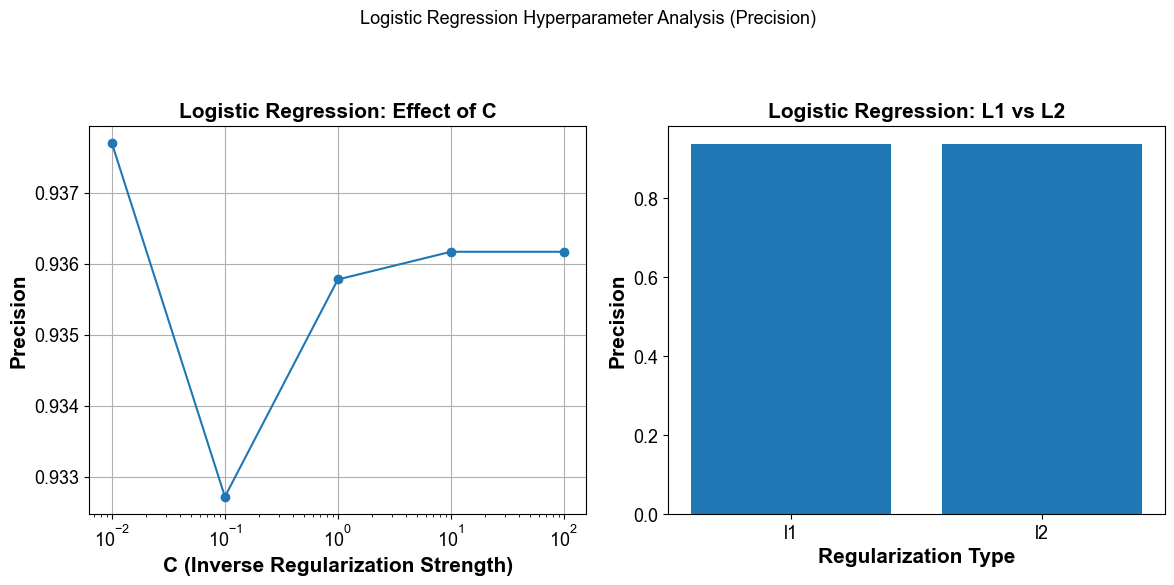

In [163]:
# Logistic Regression Hyperparameter analysis

# Precision vs C
C_values = [0.01, 0.1, 1, 10, 100]
lr_precision = []

for c in C_values:
    lr = LogisticRegression(C=c, penalty='l2', solver='liblinear', max_iter=1000)
    lr.fit(X_train_scaled, y_train)
    y_pred = lr.predict(X_test_scaled)
    lr_precision.append(precision_score(y_test, y_pred))

# L1 vs L2 Precision
penalties = ['l1', 'l2']
penalty_precision = []

for p in penalties:
    lr = LogisticRegression(penalty=p, C=1.0, solver='liblinear', max_iter=1000)
    lr.fit(X_train_scaled, y_train)
    y_pred = lr.predict(X_test_scaled)
    penalty_precision.append(precision_score(y_test, y_pred))


# ---------------- Subplots ----------------
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: C vs Precision
axes[0].plot(C_values, lr_precision, marker='o')
axes[0].set_xscale('log')
axes[0].set_xlabel("C (Inverse Regularization Strength)")
axes[0].set_ylabel("Precision")
axes[0].set_title("Logistic Regression: Effect of C")
axes[0].grid(True)

# Plot 2: L1 vs L2
axes[1].bar(penalties, penalty_precision)
axes[1].set_xlabel("Regularization Type")
axes[1].set_ylabel("Precision")
axes[1].set_title("Logistic Regression: L1 vs L2")

plt.suptitle("Logistic Regression Hyperparameter Analysis (Precision)", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("LR_hyperparameter_analysis.png", dpi=600, bbox_inches='tight')
plt.show()

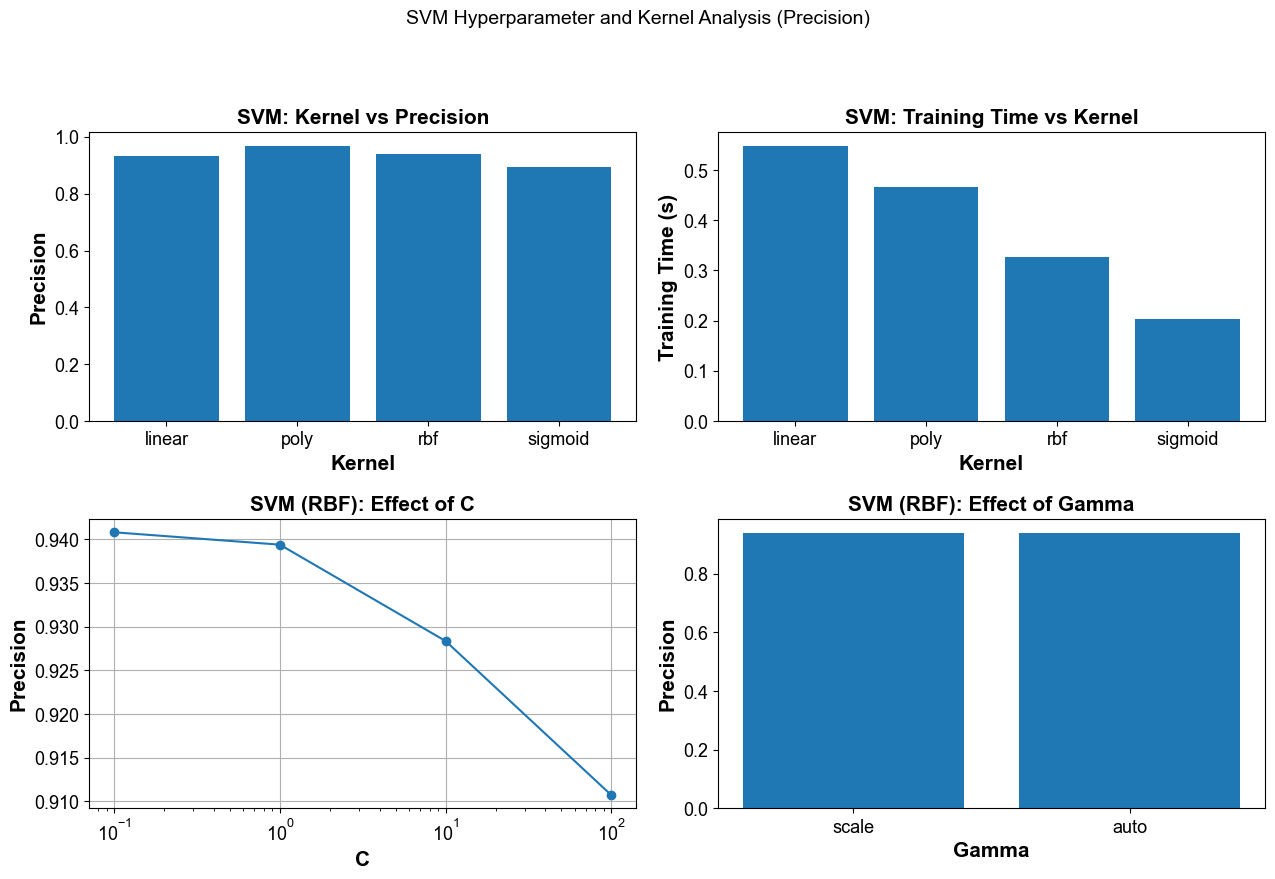

In [164]:
# SVM Hyperparameter analysis 
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
svm_precision = []
svm_time = []

for k in kernels:
    svm = SVC(kernel=k, C=1, gamma='scale')
    start = time.time()
    svm.fit(X_train_scaled, y_train)
    svm_time.append(time.time() - start)

    y_pred = svm.predict(X_test_scaled)
    svm_precision.append(precision_score(y_test, y_pred))

# Precision vs C (RBF)
C_values = [0.1, 1, 10, 100]
svm_prec_C = []

for c in C_values:
    svm = SVC(kernel='rbf', C=c, gamma='scale')
    svm.fit(X_train_scaled, y_train)
    y_pred = svm.predict(X_test_scaled)
    svm_prec_C.append(precision_score(y_test, y_pred))

# Precision vs Gamma
gamma_values = ['scale', 'auto']
gamma_prec = []

for g in gamma_values:
    svm = SVC(kernel='rbf', C=1, gamma=g)
    svm.fit(X_train_scaled, y_train)
    y_pred = svm.predict(X_test_scaled)
    gamma_prec.append(precision_score(y_test, y_pred))


# ---------------- Subplots ----------------
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Plot 1: Kernel vs Precision
axes[0, 0].bar(kernels, svm_precision)
axes[0, 0].set_title("SVM: Kernel vs Precision")
axes[0, 0].set_xlabel("Kernel")
axes[0, 0].set_ylabel("Precision")

# Plot 2: Training Time vs Kernel
axes[0, 1].bar(kernels, svm_time)
axes[0, 1].set_title("SVM: Training Time vs Kernel")
axes[0, 1].set_xlabel("Kernel")
axes[0, 1].set_ylabel("Training Time (s)")

# Plot 3: C vs Precision (RBF)
axes[1, 0].plot(C_values, svm_prec_C, marker='o')
axes[1, 0].set_xscale('log')
axes[1, 0].set_title("SVM (RBF): Effect of C")
axes[1, 0].set_xlabel("C")
axes[1, 0].set_ylabel("Precision")
axes[1, 0].grid(True)

# Plot 4: Gamma vs Precision
axes[1, 1].bar(gamma_values, gamma_prec)
axes[1, 1].set_title("SVM (RBF): Effect of Gamma")
axes[1, 1].set_xlabel("Gamma")
axes[1, 1].set_ylabel("Precision")

plt.suptitle("SVM Hyperparameter and Kernel Analysis (Precision)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("SVM_hyperparameter_analysis.png", dpi=600, bbox_inches='tight')
plt.show()
